In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
import os
from PIL import Image

def analyze_images(folder_path):
    image_count = 0
    resolutions = {}
    formats = {}

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            try:
                image_path = os.path.join(root, file)
                with Image.open(image_path) as img:
                    image_count += 1

                    resolution = img.size  # (width, height)
                    resolutions[resolution] = resolutions.get(resolution, 0) + 1

                    img_format = img.format
                    formats[img_format] = formats.get(img_format, 0) + 1
            except Exception as e:
                print(f"Error processing file {file}: {e}")

    return image_count, resolutions, formats


train_folder = r"E:\Teju\dataset\train_images"
test_folder = r"E:\Teju\dataset\test_images"

print("Analyzing Training Dataset...")
train_count, train_resolutions, train_formats = analyze_images(train_folder)
print(f"Total Training Images: {train_count}")
print(f"Training Image Resolutions: {train_resolutions}")
print(f"Training Image Formats: {train_formats}")

Analyzing Training Dataset...
Total Training Images: 3662
Training Image Resolutions: {(3216, 2136): 410, (2416, 1736): 638, (1050, 1050): 974, (2048, 1536): 351, (3388, 2588): 141, (2588, 1958): 533, (819, 614): 287, (1504, 1000): 92, (1844, 1226): 61, (4288, 2848): 52, (640, 480): 42, (2896, 1944): 34, (2144, 1424): 28, (1476, 1117): 14, (474, 358): 2, (2146, 1764): 1, (1467, 1110): 2}
Training Image Formats: {'PNG': 3662}


In [ ]:
print("\nAnalyzing Testing Dataset...")
test_count, test_resolutions, test_formats = analyze_images(test_folder)
print(f"Total Testing Images: {test_count}")
print(f"Testing Image Resolutions: {test_resolutions}")
print(f"Testing Image Formats: {test_formats}")


Analyzing Testing Dataset...
Total Testing Images: 1928
Testing Image Resolutions: {(640, 480): 1403, (2416, 1736): 225, (1050, 1050): 69, (2588, 1958): 134, (819, 614): 45, (2896, 1944): 11, (2048, 1536): 28, (768, 576): 2, (2592, 1944): 6, (1467, 1110): 2, (2146, 1764): 1, (1476, 1117): 2}
Testing Image Formats: {'PNG': 1928}


In [ ]:
import pandas as pd

def analyze_csv(file_path, dataset_name):
    try:
        data = pd.read_csv(file_path)

        print(f"\nAnalyzing {dataset_name} Dataset Metadata...")
        print(f"Number of Rows: {data.shape[0]}")
        print(f"Number of Columns: {data.shape[1]}")
        print("\nColumn Names:")
        print(data.columns)

        print("\nMissing Values Per Column:")
        print(data.isnull().sum())

        print("\nUnique Values in Each Column:")
        for column in data.columns:
            print(f"{column}: {data[column].nunique()} unique values")

        if 'label' in data.columns or 'diagnosis' in data.columns:  # Assuming the column might be 'label' or 'diagnosis'
            label_column = 'label' if 'label' in data.columns else 'diagnosis'
            print(f"\nDistribution of {label_column} Labels:")
            print(data[label_column].value_counts())

    except Exception as e:
        print(f"Error reading {file_path}: {e}")


train_csv = r"E:\Teju\dataset\train.csv"
test_csv = r"E:\Teju\dataset\test.csv"

analyze_csv(train_csv, "Training")


Analyzing Training Dataset Metadata...
Number of Rows: 3662
Number of Columns: 2

Column Names:
Index(['id_code', 'diagnosis'], dtype='object')

Missing Values Per Column:
id_code      0
diagnosis    0
dtype: int64

Unique Values in Each Column:
id_code: 3662 unique values
diagnosis: 5 unique values

Distribution of diagnosis Labels:
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [ ]:
analyze_csv(test_csv, "Testing")


Analyzing Testing Dataset Metadata...
Number of Rows: 1928
Number of Columns: 1

Column Names:
Index(['id_code'], dtype='object')

Missing Values Per Column:
id_code    0
dtype: int64

Unique Values in Each Column:
id_code: 1928 unique values


Class 0: 1805 samples


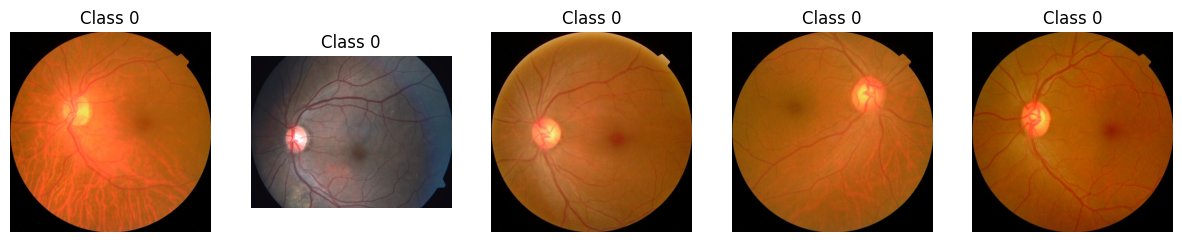

Class 1: 370 samples


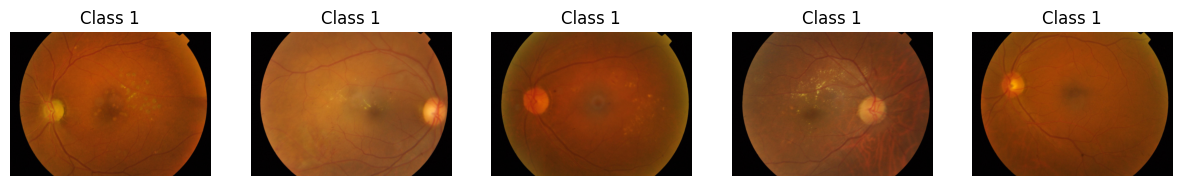

Class 2: 999 samples


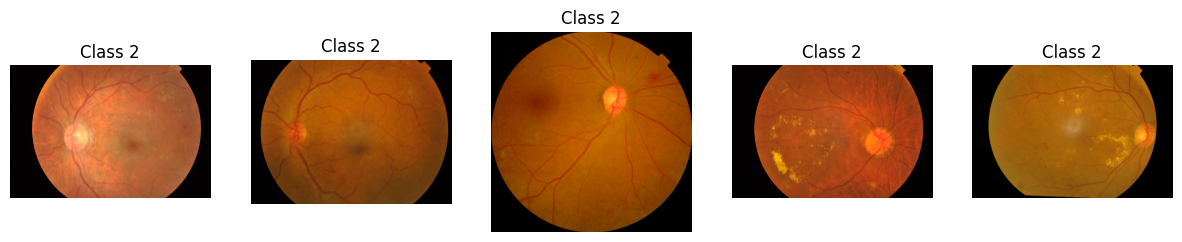

Class 3: 193 samples


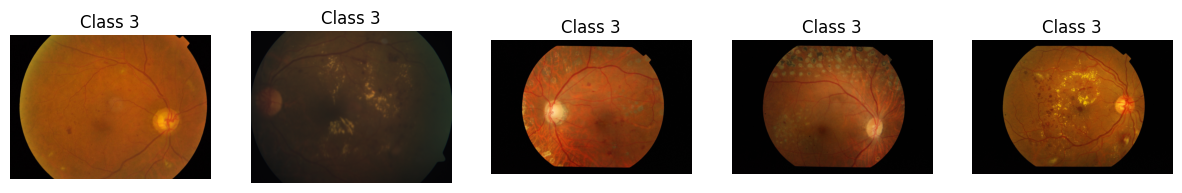

Class 4: 295 samples


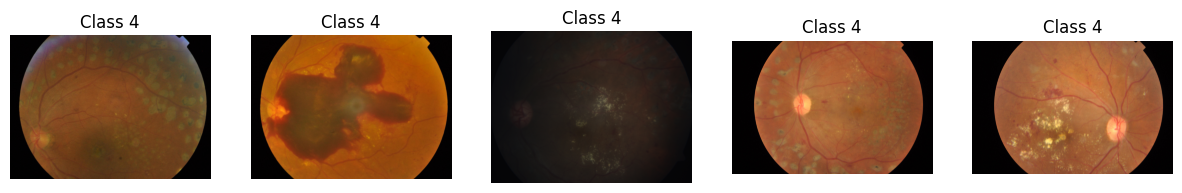

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Visualize sample images for each class
def visualize_samples(folder_path, csv_path, num_samples=5):
    import pandas as pd
    data = pd.read_csv(csv_path)
    diagnosis_groups = data.groupby('diagnosis')

    for diagnosis, group in diagnosis_groups:
        print(f"Class {diagnosis}: {len(group)} samples")
        sample_ids = group['id_code'].sample(num_samples, random_state=42).values
        plt.figure(figsize=(15, 5))
        for i, sample_id in enumerate(sample_ids):
            file_path = os.path.join(folder_path, f"{sample_id}.png")
            if os.path.exists(file_path):
                img = Image.open(file_path)
                plt.subplot(1, num_samples, i + 1)
                plt.imshow(img)
                plt.title(f"Class {diagnosis}")
                plt.axis('off')
        plt.show()

# Update the paths accordingly
train_folder = r"E:\Teju\dataset\train_images"
train_csv = r"E:\Teju\dataset\train.csv"

visualize_samples(train_folder, train_csv)


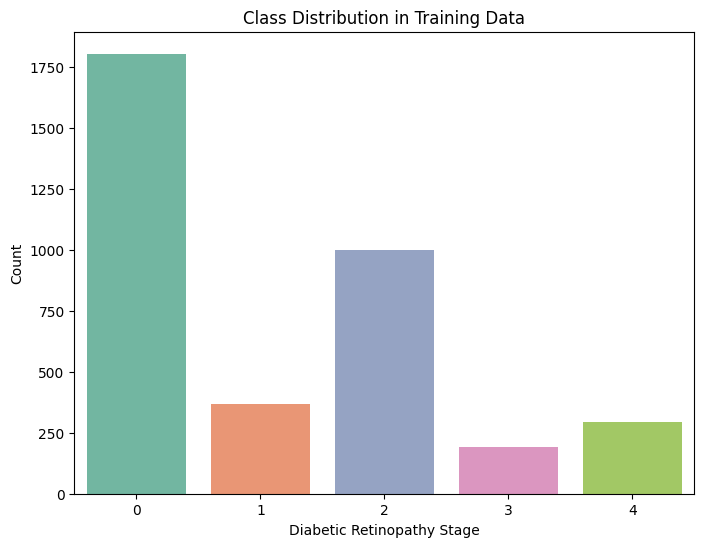

In [ ]:
import pandas as pd
import seaborn as sns

# Load training CSV
data = pd.read_csv(train_csv)

# Plot class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', hue='diagnosis', data=data, palette='Set2', legend=False)
plt.title("Class Distribution in Training Data")
plt.xlabel("Diabetic Retinopathy Stage")
plt.ylabel("Count")
plt.show()

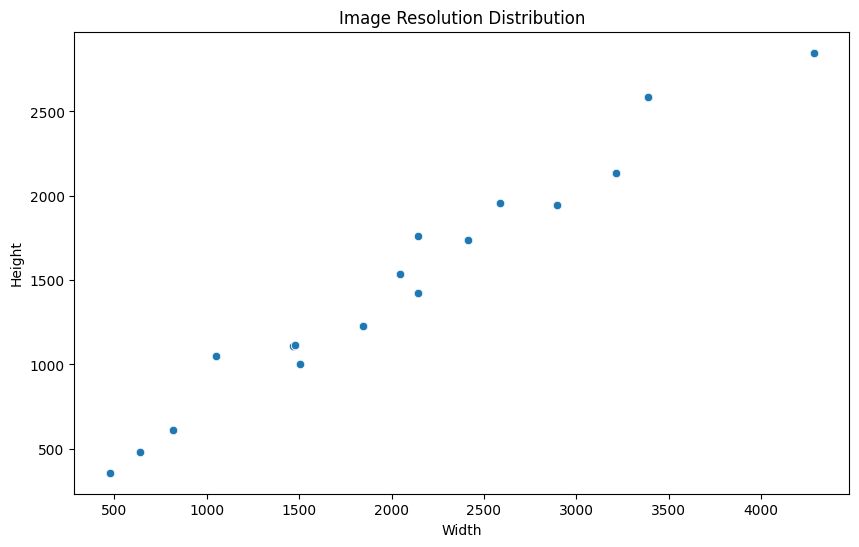

Image Resolution Summary:
             Width       Height
count  3662.000000  3662.000000
mean   2015.176679  1526.830147
std     884.301940   542.663120
min     474.000000   358.000000
25%    1050.000000  1050.000000
50%    2144.000000  1536.000000
75%    2588.000000  1958.000000
max    4288.000000  2848.000000


In [ ]:
def image_statistics(folder_path):
    from PIL import Image
    resolutions = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            try:
                image_path = os.path.join(root, file)
                with Image.open(image_path) as img:
                    resolutions.append(img.size)
            except Exception as e:
                print(f"Error processing file {file}: {e}")

    return resolutions

# Analyze training images
resolutions = image_statistics(train_folder)
resolution_df = pd.DataFrame(resolutions, columns=['Width', 'Height'])

# Plot resolution distribution
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Width', y='Height', data=resolution_df)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

# Summary statistics of resolutions
print("Image Resolution Summary:")
print(resolution_df.describe())

In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import pandas as pd
import shutil

# Preprocessing function
def preprocess_image(image_path, output_size=(224, 224)):
    # Read the image
    img = cv2.imread(image_path)

    # Crop the central region (removing dark parts)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    x, y, w, h = cv2.boundingRect(thresh)
    cropped_img = img[y:y+h, x:x+w]

    # Resize to the desired size
    resized_img = cv2.resize(cropped_img, output_size)

    # Enhance contrast
    lab = cv2.cvtColor(resized_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    enhanced_img = cv2.merge((l, a, b))
    enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_LAB2BGR)

    # Normalize
    normalized_img = enhanced_img / 255.0

    return normalized_img

# Preprocess images and organize them into class folders
def preprocess_and_organize(input_folder, output_folder, csv_path, output_size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)

    # Load class labels
    data = pd.read_csv(csv_path)
    id_to_class = data.set_index('id_code')['diagnosis'].to_dict()

    for file_name in tqdm(os.listdir(input_folder), desc="Preprocessing Images", unit="image"):
        input_path = os.path.join(input_folder, file_name)
        img_id = file_name.split('.')[0]  # Extract id_code from filename
        if img_id in id_to_class:
            class_label = f"class_{id_to_class[img_id]}"
            class_folder = os.path.join(output_folder, class_label)
            os.makedirs(class_folder, exist_ok=True)

            output_path = os.path.join(class_folder, file_name)
            try:
                preprocessed_img = preprocess_image(input_path, output_size)
                cv2.imwrite(output_path, (preprocessed_img * 255).astype(np.uint8))
            except Exception as e:
                print(f"Error processing {file_name}: {e}")

# Paths
train_folder = r"E:\Teju\dataset\train_images"
train_csv = r"E:\Teju\dataset\train.csv"
preprocessed_folder = r"E:\Teju\dataset\preprocessed_train_images"

preprocess_and_organize(train_folder, preprocessed_folder, train_csv)


Preprocessing Images: 100%|██████████| 3662/3662 [03:05<00:00, 19.76image/s]


In [ ]:
import tensorflow as tf
from tqdm import tqdm
import os

# Augmentation parameters
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Augment images and save to a new folder
def augment_images(input_folder, output_folder, batch_size=32, num_samples_per_class=500):
    os.makedirs(output_folder, exist_ok=True)

    for class_folder in os.listdir(input_folder):
        class_path = os.path.join(input_folder, class_folder)
        if os.path.isdir(class_path):
            augmented_class_folder = os.path.join(output_folder, class_folder)
            os.makedirs(augmented_class_folder, exist_ok=True)

            generator = datagen.flow_from_directory(
                input_folder,
                target_size=(224, 224),
                batch_size=batch_size,
                classes=[class_folder],
                class_mode=None,  # Set to None for image augmentation only
                save_to_dir=augmented_class_folder,
                save_prefix='aug_',  # Optional prefix for augmented images
                save_format='png'
            )

            # Generate augmented images
            total_batches = num_samples_per_class // batch_size
            for _ in tqdm(range(total_batches), desc=f"Augmenting {class_folder}", unit="batch"):
                next(generator)

# Paths
augmented_folder = r"E:\Teju\dataset\augmented_train_images"
augment_images(preprocessed_folder, augmented_folder)

Found 1805 images belonging to 1 classes.


Augmenting class_0: 100%|██████████| 15/15 [00:10<00:00,  1.40batch/s]

Found 370 images belonging to 1 classes.



Augmenting class_1: 100%|██████████| 15/15 [00:10<00:00,  1.46batch/s]

Found 999 images belonging to 1 classes.



Augmenting class_2: 100%|██████████| 15/15 [00:11<00:00,  1.32batch/s]

Found 193 images belonging to 1 classes.



Augmenting class_3: 100%|██████████| 15/15 [00:08<00:00,  1.68batch/s]

Found 295 images belonging to 1 classes.



Augmenting class_4: 100%|██████████| 15/15 [00:10<00:00,  1.49batch/s]


In [ ]:
import os

def check_class_folders(folder_path):
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            print(f"{class_folder}: {len(os.listdir(class_path))} images")

# Check preprocessed folder
print("Preprocessed Folder:")
check_class_folders(preprocessed_folder)

# Check augmented folder
print("\nAugmented Folder:")
check_class_folders(augmented_folder)


Preprocessed Folder:
class_0: 1805 images
class_1: 370 images
class_2: 999 images
class_3: 193 images
class_4: 295 images

Augmented Folder:
class_0: 480 images
class_1: 466 images
class_2: 480 images
class_3: 418 images
class_4: 455 images



Visualizing samples for class_0:


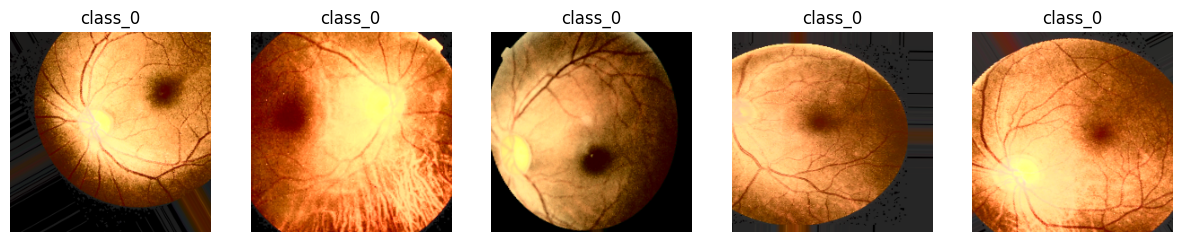


Visualizing samples for class_1:


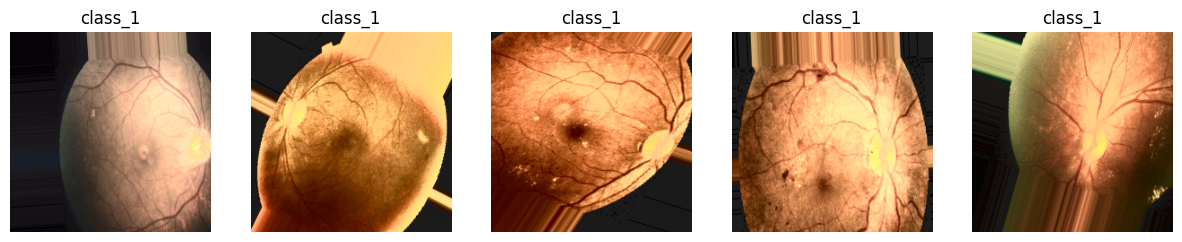


Visualizing samples for class_2:


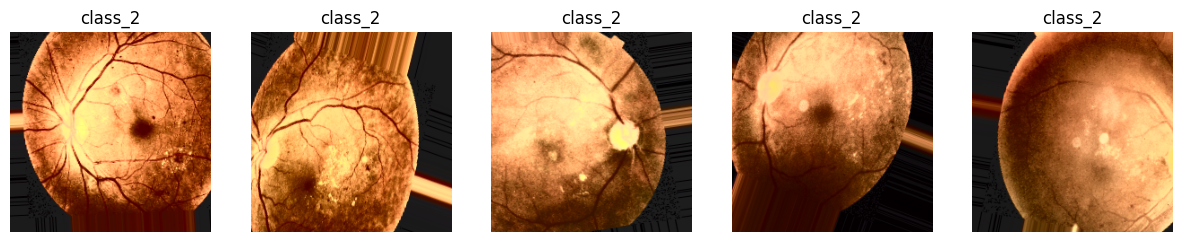


Visualizing samples for class_3:


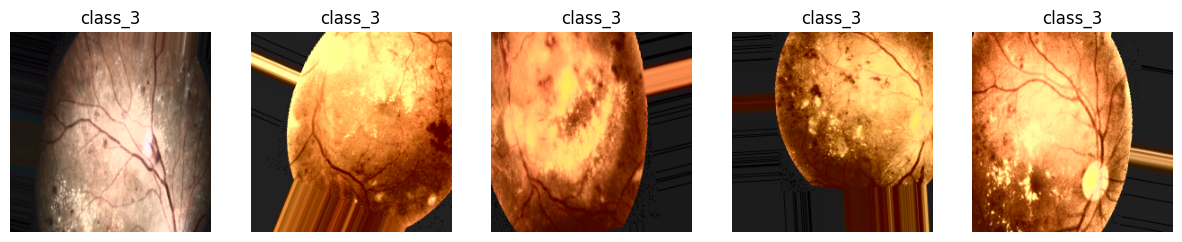


Visualizing samples for class_4:


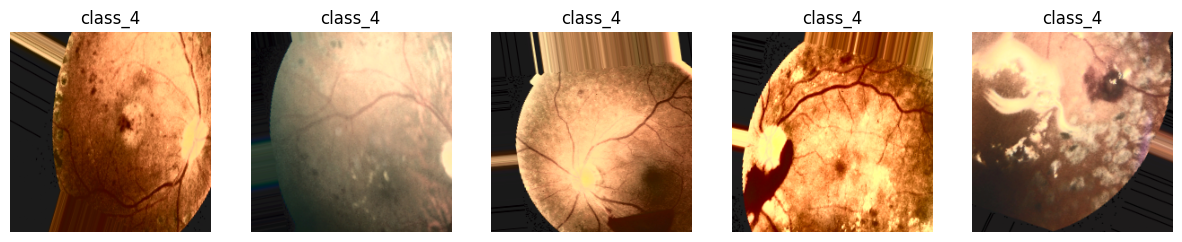

In [ ]:
import matplotlib.pyplot as plt
import random

def visualize_augmented_samples(folder_path, num_samples=5):
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            print(f"\nVisualizing samples for {class_folder}:")
            sample_files = random.sample(os.listdir(class_path), num_samples)
            plt.figure(figsize=(15, 5))
            for i, file_name in enumerate(sample_files):
                file_path = os.path.join(class_path, file_name)
                img = plt.imread(file_path)
                plt.subplot(1, num_samples, i + 1)
                plt.imshow(img)
                plt.title(class_folder)
                plt.axis('off')
            plt.show()

visualize_augmented_samples(augmented_folder)


In [ ]:
# Dataset paths
train_dir = r"E:\Teju\dataset\augmented_train_images"
test_dir = r"E:\Teju\dataset\preprocessed_train_images"  # Use part for testing


In [ ]:
# Define generators for training, validation, and testing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2  # Split training data into train and validation sets
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1840 images belonging to 5 classes.
Found 459 images belonging to 5 classes.
Found 3662 images belonging to 5 classes.


In [ ]:
# Load pre-trained ResNet50 and add custom layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 classes for diabetic retinopathy
])

# Freeze base model layers to prevent updates during training
base_model.trainable = False

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,279,365 (187.99 MB)

 Trainable params: 25,691,653 (98.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

C:\Users\mouli\anaconda3_new\envs\project\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
38/58 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1922 - loss: 8.5837

In [ ]:
import os
import shutil
import pandas as pd

def organize_augmented_images(augmented_folder, train_csv):
    # Load class labels from the CSV
    train_data = pd.read_csv(train_csv)
    id_to_class = train_data.set_index('id_code')['diagnosis'].to_dict()

    # Create class folders and move files
    for file_name in os.listdir(augmented_folder):
        if file_name.endswith('.png'):
            img_id = file_name.split('.')[0]  # Assuming filenames are like '<id_code>.png'
            if img_id in id_to_class:
                class_label = f"class_{id_to_class[img_id]}"
                class_folder = os.path.join(augmented_folder, class_label)
                os.makedirs(class_folder, exist_ok=True)

                src_path = os.path.join(augmented_folder, file_name)
                dest_path = os.path.join(class_folder, file_name)
                shutil.move(src_path, dest_path)

# Paths
augmented_folder = r"E:\Teju\dataset\augmented_train_images"
train_csv = r"E:\Teju\dataset\train.csv"

organize_augmented_images(augmented_folder, train_csv)


In [ ]:
import matplotlib.pyplot as plt
import random
import os

def visualize_augmented_samples_debug(folder_path, num_samples=5):
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            print(f"\nChecking samples for {class_folder}:")
            sample_files = os.listdir(class_path)
            if not sample_files:
                print(f"No files found in {class_folder}")
                continue

            sample_files = random.sample(sample_files, min(num_samples, len(sample_files)))
            plt.figure(figsize=(15, 5))
            for i, file_name in enumerate(sample_files):
                file_path = os.path.join(class_path, file_name)
                print(f"Loading file: {file_path}")  # Debug log
                img = plt.imread(file_path)
                plt.subplot(1, num_samples, i + 1)
                plt.imshow(img)
                plt.title(class_folder)
                plt.axis('off')
            plt.show()

visualize_augmented_samples_debug(augmented_folder)


In [ ]:
import os

def validate_augmented_data(folder_path):
    class_counts = {}
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            class_counts[class_folder] = len(os.listdir(class_path))
    return class_counts

augmented_folder = r"E:\Teju\dataset\augmented_train_images"
class_counts = validate_augmented_data(augmented_folder)
print("Class-wise Augmented Image Counts:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")


Class-wise Augmented Image Counts:


In [ ]:
import matplotlib.pyplot as plt
import random

def visualize_augmented_samples(folder_path, num_samples=5):
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            print(f"\nVisualizing samples for {class_folder}:")
            sample_files = random.sample(os.listdir(class_path), num_samples)
            plt.figure(figsize=(15, 5))
            for i, file_name in enumerate(sample_files):
                file_path = os.path.join(class_path, file_name)
                img = plt.imread(file_path)
                plt.subplot(1, num_samples, i + 1)
                plt.imshow(img)
                plt.title(class_folder)
                plt.axis('off')
            plt.show()

visualize_augmented_samples(augmented_folder)


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

train_csv = r"E:\Teju\dataset\train.csv"
data = pd.read_csv(train_csv)

train, valid = train_test_split(data, test_size=0.2, stratify=data['diagnosis'], random_state=42)

train.to_csv(r"E:\Teju\dataset\train_split.csv", index=False)
valid.to_csv(r"E:\Teju\dataset\valid_split.csv", index=False)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Example for training set
train_generator = datagen.flow_from_directory(
    resized_train_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 0 images belonging to 0 classes.


In [ ]:
def augment_minority_classes(data, folder_path, save_path, target_size=(224, 224)):
    os.makedirs(save_path, exist_ok=True)
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    for diagnosis, group in data.groupby('diagnosis'):
        if len(group) < 1000:  # Assuming 1000 as the desired number of samples
            sample_ids = group['id_code']
            for sample_id in sample_ids:
                img_path = os.path.join(folder_path, f"{sample_id}.png")
                if os.path.exists(img_path):
                    img = load_img(img_path, target_size=target_size)
                    img_array = img_to_array(img)
                    img_array = np.expand_dims(img_array, axis=0)

                    # Generate augmented images
                    count = 0
                    for batch in datagen.flow(img_array, batch_size=1, save_to_dir=save_path, save_prefix=f"{sample_id}_aug"):
                        count += 1
                        if count >= 5:  # Generate 5 augmented samples per image
                            break


Displaying color images by diagnosis (256x256)...


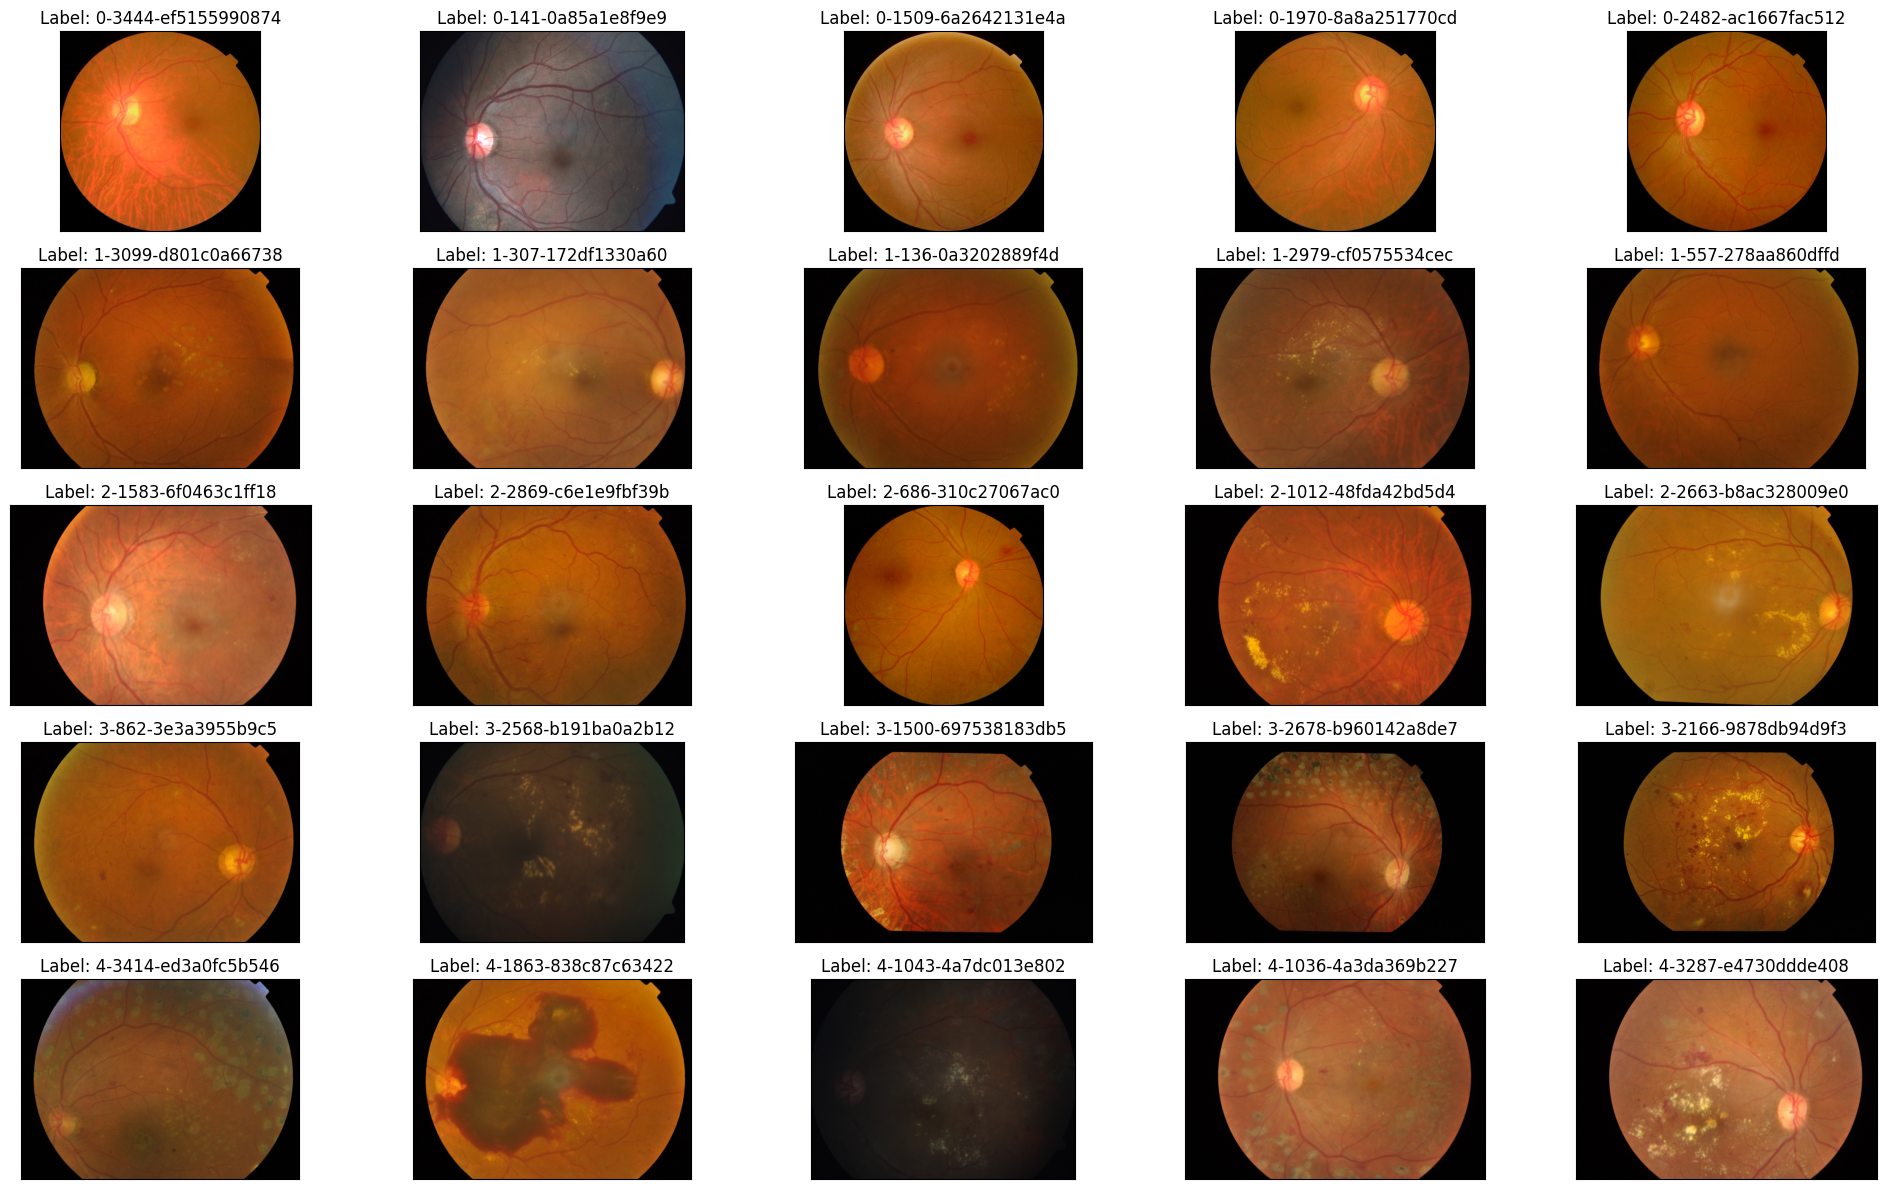

In [ ]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os

train_csv_path = r"E:\Teju\dataset\train.csv"
train_images_path = r"E:\Teju\dataset\train_images"

train = pd.read_csv(train_csv_path)

def showbyserverity(df, images_path):

    fig = plt.figure(figsize=(20, 12))
    for class_id in sorted(df['diagnosis'].unique()):
        for i, (idx, row) in enumerate(df.loc[df['diagnosis'] == class_id].sample(5, random_state=42).iterrows()):
            ax = fig.add_subplot(5, 5, class_id * 5 + i + 1, xticks=[], yticks=[])
            path = os.path.join(images_path, f"{row['id_code']}.png")
            image = cv2.imread(path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for Matplotlib
                ax.imshow(image)
                ax.set_title(f'Label: {class_id}-{idx}-{row["id_code"]}')
            else:
                ax.axis('off')
                ax.set_title(f'Missing Image')
    plt.tight_layout()
    plt.show()

def showbyserverity_GRAY(df, images_path):
    fig = plt.figure(figsize=(20, 12))
    for class_id in sorted(df['diagnosis'].unique()):
        for i, (idx, row) in enumerate(df.loc[df['diagnosis'] == class_id].sample(5, random_state=42).iterrows()):
            ax = fig.add_subplot(5, 5, class_id * 5 + i + 1, xticks=[], yticks=[])
            path = os.path.join(images_path, f"{row['id_code']}.png")
            image = cv2.imread(path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                ax.imshow(image, cmap='gray')
                ax.set_title(f'Label: {class_id}-{idx}-{row["id_code"]}')
            else:
                ax.axis('off')
                ax.set_title(f'Missing Image')
    plt.tight_layout()
    plt.show()

print("Displaying color images by diagnosis (256x256)...")
showbyserverity(train, train_images_path)

Displaying grayscale images by diagnosis (256x256)...


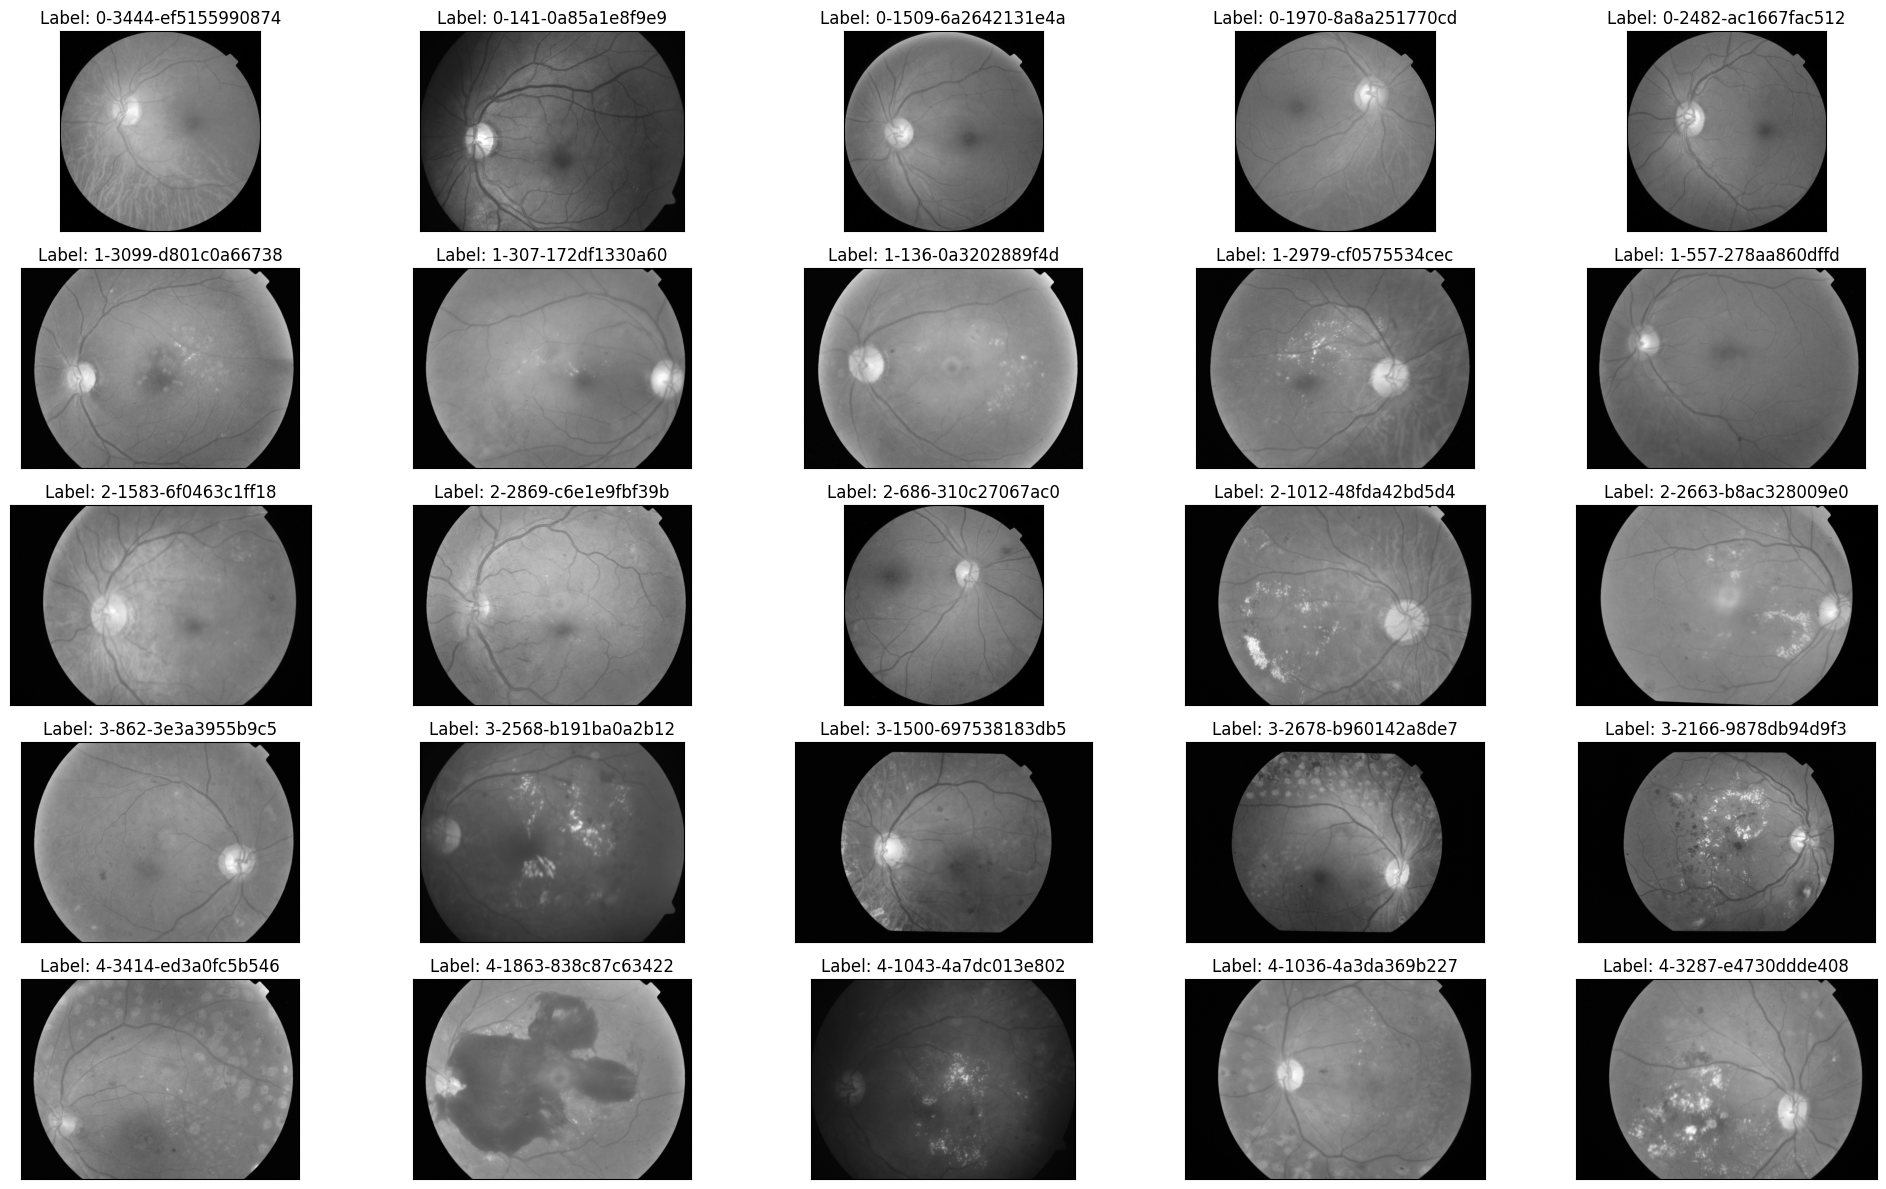

In [ ]:
print("Displaying grayscale images by diagnosis (256x256)...")
showbyserverity_GRAY(train, train_images_path)

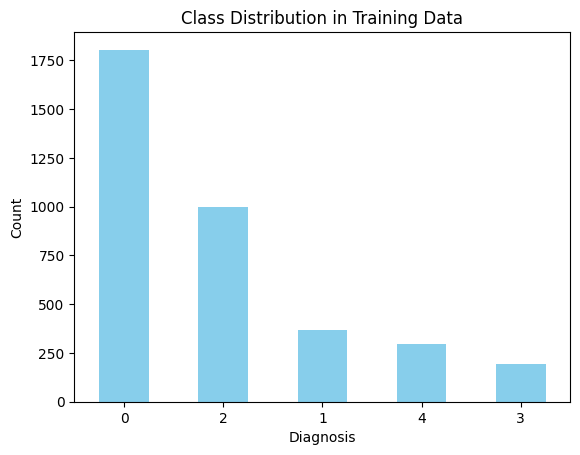

In [ ]:
import matplotlib.pyplot as plt

train_df['diagnosis'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Class Distribution in Training Data")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


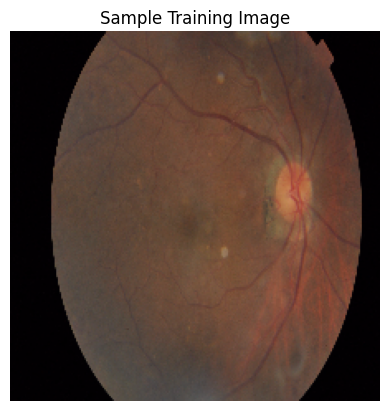

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

train_image = []
train_label = []

def label_img(label):
    encoding = np.zeros(5)
    encoding[label] = 1
    return encoding

for i, j in train.values:
    path = f"E:/project dataset 2/train_images/{i}.png"
    image = cv2.imread(path)
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        train_image.append(np.array(image) / 255)
        train_label.append(label_img(j))

xTrain, xTest, yTrain, yTest = train_test_split(train_image, train_label, test_size=0.25, random_state=42)
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size=0.15, random_state=42)

xTrain = np.array(xTrain)
xTest = np.array(xTest)
xVal = np.array(xVal)
yTrain = np.array(yTrain)
yTest = np.array(yTest)
yVal = np.array(yVal)

plt.imshow(xTrain[219])
plt.title("Sample Training Image")
plt.axis('off')
plt.show()


C:\Users\mouli\anaconda3_new\envs\project\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 405ms/step - accuracy: 0.4945 - loss: 1.5455 - val_accuracy: 0.6772 - val_loss: 0.8814
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 389ms/step - accuracy: 0.6898 - loss: 0.8598 - val_accuracy: 0.6723 - val_loss: 0.8610
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 387ms/step - accuracy: 0.7119 - loss: 0.7793 - val_accuracy: 0.6796 - val_loss: 0.8590
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 385ms/step - accuracy: 0.6973 - loss: 0.8074 - val_accuracy: 0.7184 - val_loss: 0.8178
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 384ms/step - accuracy: 0.7196 - loss: 0.7567 - val_accuracy: 0.7039 - val_loss: 0.8143
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.7329 - loss: 0.7402 - val_accuracy: 0.6723 - val_loss: 0.8049
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.7222 - loss: 0.7393 - val_accuracy: 0.7160 - val_loss: 0.7906
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 385ms/step - accuracy: 0.7263 - loss: 0.7408 - val_accu

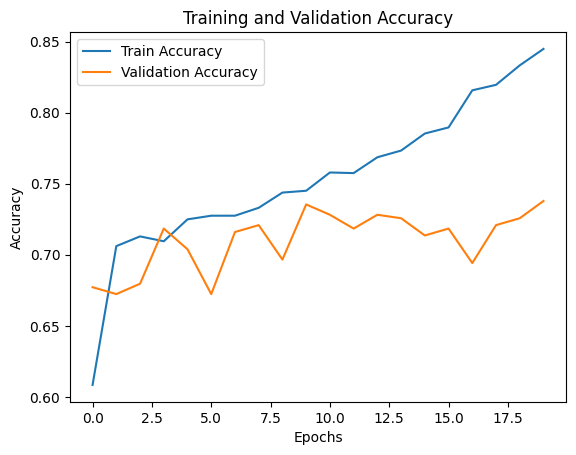

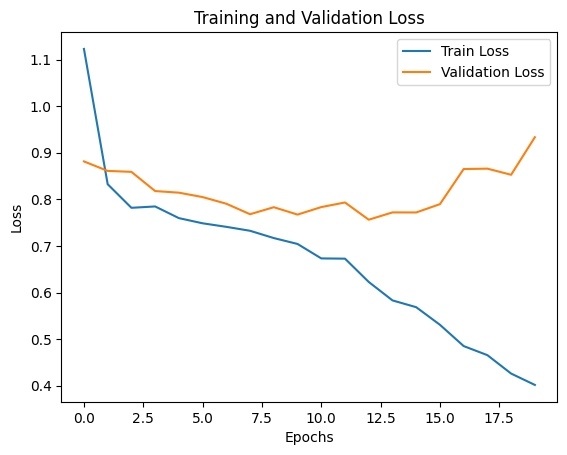

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    xTrain, yTrain,
    validation_data=(xVal, yVal),
    epochs=20,
    batch_size=32,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(xTest, yTest)
print(f"Test Accuracy: {test_accuracy}")

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
